<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

# Afficher toutes les colonnes d'un DataFrame
pd.set_option('display.max_columns', None)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel(r"C:\Users\imanb\Desktop\Projet6\Mission\Data+Bottleneck\web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel(r"C:\Users\imanb\Desktop\Projet6\Mission\Data+Bottleneck\erp.xlsx")

#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel(r"C:\Users\imanb\Desktop\Projet6\Mission\Data+Bottleneck\liaison.xlsx")

C:\Users\imanb\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\imanb\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\imanb\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp["product_id"].duplicated().sum()

np.int64(0)

In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?

print(df_erp["stock_status"].unique())

print(df_erp.groupby("stock_status")["stock_quantity"].min())

df_erp[df_erp["stock_quantity"] < 0]

['instock' 'outofstock']
stock_status
instock        0
outofstock   -10
Name: stock_quantity, dtype: int64


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30


In [10]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(
    lambda x: "outofstock" if x <= 0 else "instock"
)

df_erp[["stock_quantity", "stock_status", "stock_status_2"]].head()


,stock_quantity,stock_status,stock_status_2
0,16,instock,instock
1,10,instock,instock
2,0,outofstock,outofstock
3,26,instock,instock
4,3,outofstock,instock


In [11]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [12]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset


(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()


np.int64(823)

In [13]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [14]:
#Corriger la ou les données incohérentes

#Vérification en utilisant le même code que plus haut pour afficher les problèmes

df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"], "stock_status"] = df_erp["stock_status_2"]

df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [15]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
print("Nombres d'articles avec un prix non renseigné : {}".format(df_erp["price"].isna().sum()))

#Afficher le ou les prix non renseignés dans la colonne "price"

 #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print("Prix minimum :", df_erp["price"].min())

#Afficher le prix maximum de la colonne "price"
print("Prix maximum :", df_erp["price"].max())

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)


print("\nProduits avec un prix négatif :")
print(df_erp[df_erp["price"] < 0])


Nombres d'articles avec un prix non renseigné : 0
Prix minimum : -20.0
Prix maximum : 225.0

Produits avec un prix négatif :
     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  


In [16]:
# Suppression des produits ayant un prix négatif
df_erp = df_erp[df_erp["price"] >= 0].copy()



In [17]:
#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
df_erp.loc[df_erp['price']<0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [18]:
#######################
### stock_quantity  ###
#######################

# Vérification de la colonne stock_quantity
print("Stock minimum :", df_erp["stock_quantity"].min())
print("Stock maximum :", df_erp["stock_quantity"].max())

# Produits avec un stock négatif (à auditer)
df_stock_neg = df_erp[df_erp["stock_quantity"] < 0].copy()

# On conserve uniquement les stocks valides
df_erp = df_erp[df_erp["stock_quantity"] >= 0].copy()

print("Stocks négatifs :", len(df_stock_neg))
print("Produits analysés :", len(df_erp))




Stock minimum : -10
Stock maximum : 145
Stocks négatifs : 2
Produits analysés : 820


In [19]:
display(df_erp.loc[df_erp['stock_quantity']<0,:])


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [20]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp["onsale_web"].value_counts()



onsale_web
1    715
0    105
Name: count, dtype: int64

In [21]:
#Quelles sont les colonnes à conserver selon vous?
# Colonnes conservées :
# product_id, onsale_web, price, stock_quantity,
# stock_status, purchase_price
#
# Colonne supprimée :
# stock_status_2 (redondante avec stock_status)

In [22]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".

df_erp = df_erp.drop(columns=["stock_status_2"], errors="ignore")


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [23]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombre d'articles avec un prix d'achat non renseigné :",
      df_erp["purchase_price"].isna().sum())

#Afficher le prix minimum de la colonne "purchase_price"
print("Prix d'achat minimum :", df_erp["purchase_price"].min())
#Afficher le prix maximum de la colonne "purchase_price"
print("Prix d'achat maximum :", df_erp["purchase_price"].max())

Nombre d'articles avec un prix d'achat non renseigné : 0
Prix d'achat minimum : 2.74
Prix d'achat maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [24]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observations".format(df_web.shape[0]))

#Nombre de caractéristiques
print("Le tableau comporte {} colonnes".format(df_web.shape[1]))

Le tableau comporte 1513 observations
Le tableau comporte 29 colonnes


In [25]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [26]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop(columns=[
    "tax_class",
    "post_content",
    "post_password",
    "post_content_filtered"
])

In [27]:
#Visualisation des valeurs de la colonne sku (unique)
df_web["sku"].apply(type).value_counts()
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
df_web[df_web["sku"].apply(type) == str]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
272,13127-1,0,0,0,0.0,4.0,taxable,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",publish,closed,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,Autre,Bon cadeau de 25€,NaN,publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1117,13127-1,0,0,0,0.0,4.0,NaN,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,NaN,publish,closed,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [28]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
df_web[df_web["sku"].isna()]
# Analyse :
# 85 lignes n'ont pas de SKU.
# Ces lignes sont presque entièrement vides.
# Elles ne correspondent pas à des produits exploitables.

# Action :
# Supprimer ces lignes avant les analyses et les jointures.



,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df_web = df_web.dropna(subset=["sku"])

In [30]:
df_web["sku"].isna().sum()

np.int64(0)

In [31]:
#Identifier les lignes sans code article
df_web[df_web["sku"].isna()]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count


In [32]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
df_web["sku"].duplicated().sum()

np.int64(714)

In [33]:
df_web[df_web["sku"].duplicated()]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
56,12869,0,0,0,0.0,7.0,NaN,2.0,2019-03-28 14:29:35,2019-03-28 13:29:35,Vin,Stéphane Tissot Arbois D.D. 2016,NaN,publish,closed,closed,stephane-tissot-arbois-dd-2016,2019-12-13 15:40:01,2019-12-13 14:40:01,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
74,13809,0,0,0,0.0,8.0,taxable,2.0,2018-05-15 11:11:59,2018-05-15 09:11:59,Vin,Antoine-Marie Arena Vin de France Rouge San Gi...,Ce vin montre de la précision et de la justess...,publish,closed,closed,antoine-marie-arena-vin-de-france-rouge-san-gi...,2020-04-23 22:54:55,2020-04-23 20:54:55,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
109,15758,0,0,0,0.0,18.0,taxable,2.0,2018-02-16 10:54:27,2018-02-16 09:54:27,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,"Un Touraine Amboise fin et élégant, un joli ch...",publish,closed,closed,frissant-chenin-pierres-2018,2020-08-27 11:45:02,2020-08-27 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
117,13766,0,0,0,0.0,2.0,NaN,2.0,2018-03-22 10:35:08,2018-03-22 09:35:08,Whisky,Wemyss Malts Blended Malt Scotch Whisky Treacl...,NaN,publish,closed,closed,whisky-wemyss-treacle-chest,2020-07-20 09:30:05,2020-07-20 07:30:05,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
137,16580,0,0,0,0.0,8.0,taxable,2.0,2019-07-24 09:31:48,2019-07-24 07:31:48,Vin,Domaine Giudicelli Patrimonio Blanc 2019,Ce Patrimonio Blanc signé Muriel Giudicelli no...,publish,closed,closed,domaine-giudicelli-patrimonio-blanc-2019,2020-08-27 10:12:58,2020-08-27 08:12:58,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16326,0,0,0,0.0,5.0,taxable,2.0,2019-04-18 11:32:46,2019-04-18 09:32:46,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,"Sur le millésime 2017, Au Capceu du domaine Ca...",publish,closed,closed,camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1509,15662,0,0,0,0.0,15.0,taxable,2.0,2018-02-27 10:13:03,2018-02-27 09:13:03,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,"C'est le Beaujolais typique : fruité, frais, g...",publish,closed,closed,chermette-domaine-du-vissoux-beaujolais-griott...,2020-07-11 11:25:03,2020-07-11 09:25:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1510,15329,0,0,0,0.0,3.0,NaN,2.0,2019-03-27 18:28:15,2019-03-27 17:28:15,Vin,Agnès Levet Côte Rôtie Péroline 2017,NaN,publish,closed,closed,agnes-levet-cote-rotie-peroline-2017,2020-07-28 09:45:02,2020-07-28 07:45:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1511,14827,0,0,0,0.0,7.0,NaN,2.0,2018-11-26 09:56:52,2018-11-26 08:56:52,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,NaN,publish,closed,closed,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-07-28 09:45:02,2020-07-28 07:45:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [34]:
df_web[df_web["sku"].duplicated(keep=False)].head(20)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
5,15471,0,0,0,0.0,4.0,NaN,2.0,2019-03-19 15:58:25,2019-03-19 14:58:25,Vin,Château d'Arcole Saint-Emilion Grand Cru 2016,NaN,publish,closed,closed,arcole-saint-emilion-grand-cru-2016,2020-06-18 10:45:05,2020-06-18 08:45:05,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
6,16515,0,0,0,0.0,10.0,taxable,2.0,2018-06-02 09:31:31,2018-06-02 07:31:31,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,"<div id=""wrapper"">\n<div id=""container-wrapper...",publish,closed,closed,chateau-turcaud-bordeaux-rouge-cuvee-majeure-2018,2020-08-27 10:11:12,2020-08-27 08:11:12,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
7,16246,0,0,0,0.0,10.0,NaN,2.0,2018-02-28 14:46:15,2018-02-28 13:46:15,Vin,Domaine de La Tour Du Bon Bandol Blanc 2019,NaN,publish,closed,closed,la-tour-du-bon-bandol-blanc-2019,2020-08-26 15:55:03,2020-08-26 13:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
9,13572,0,0,0,0.0,17.0,NaN,2.0,2019-03-19 11:33:39,2019-03-19 10:33:39,Vin,Château Tour Haut-Caussan Médoc 2015,NaN,publish,closed,closed,tour-haut-caussan-medoc-2015,2020-08-26 16:55:02,2020-08-26 14:55:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
10,16513,0,0,0,0.0,13.0,NaN,2.0,2018-04-17 22:20:31,2018-04-17 20:20:31,Vin,Domaine Schoenheitz Riesling Herrenreben 2018,NaN,publish,closed,closed,domaine-schoenheitz-riesling-herrenreben-2018,2020-08-26 15:55:04,2020-08-26 13:55:04,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [35]:
df_web["post_type"].value_counts()

post_type
attachment    714
product       714
Name: count, dtype: int64

In [36]:
df_web = df_web[df_web["post_type"] == "product"]

In [37]:
df_web["post_type"].value_counts()

post_type
product    714
Name: count, dtype: int64

In [38]:
df_web["sku"].duplicated().sum()

np.int64(0)

In [39]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_sku = df_web[df_web["sku"].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sans_sku.info()
#3 - Que constatez-vous?
# Constat :
# Les 85 lignes sans SKU sont quasiment vides.
# La majorité des colonnes ne contient aucune information.
# Seules quelques colonnes possèdent 2 valeurs renseignées.
# Ces lignes ne correspondent pas à de véritables produits exploitables.

# Action :
# Ces lignes pourront être supprimées du dataset avant les analyses
# et les jointures avec les autres fichiers.

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            0 non-null      int64         
 2   downloadable       0 non-null      int64         
 3   rating_count       0 non-null      int64         
 4   average_rating     0 non-null      float64       
 5   total_sales        0 non-null      float64       
 6   tax_status         0 non-null      object        
 7   post_author        0 non-null      float64       
 8   post_date          0 non-null      datetime64[ns]
 9   post_date_gmt      0 non-null      datetime64[ns]
 10  product_type       0 non-null      object        
 11  post_title         0 non-null      object        
 12  post_excerpt       0 non-null      object        
 13  post_status        0 non-null      object        
 14  comment_status     0 non-nu

In [40]:
df_web["sku"].isna().sum()

np.int64(0)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [41]:

#Nombre d'observations
print("Le tableau comporte {} observations".format(df_liaison.shape[0]))
#Nombre de caractérisqtiques
print("Le tableau comporte {} colonnes".format(df_liaison.shape[1]))




Le tableau comporte 825 observations
Le tableau comporte 2 colonnes


In [42]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

# Constat :
# La colonne product_id est complète.
# La colonne id_web contient 91 valeurs manquantes.
# Certains produits de l'ERP ne sont donc pas associés à un produit du site web.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [43]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison["product_id"].duplicated().sum()

np.int64(0)

In [44]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison["id_web"].dropna().duplicated().sum()

np.int64(0)

In [45]:
#Avons-nous des articles sans correspondance?
df_liaison["id_web"].isna().sum()

np.int64(91)

In [46]:
# Constat :
# 91 produits ne possèdent pas d'identifiant id_web.
# Ces produits n'ont donc pas de correspondance avec le site web.
# Ils existent dans l'ERP mais ne sont pas associés à un produit du fichier web.

In [47]:
# vision des doublons
display(df_liaison.loc[df_liaison['id_web'].duplicated(),:])
print('les doublons sont les lignes avec les id_web vides')


,id_web,product_id
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
151,NaN,4233
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


les doublons sont les lignes avec les id_web vides


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [48]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = pd.merge(df_erp, df_liaison, on="product_id", how="outer", indicator=True)

In [49]:
df_erp_liaison.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1.0,24.2,16.0,instock,12.88,15298,both
1,3849,1.0,34.3,10.0,instock,17.54,15296,both
2,3850,1.0,20.8,0.0,outofstock,10.64,15300,both
3,4032,1.0,14.1,26.0,instock,6.92,19814,both
4,4039,1.0,46.0,3.0,instock,23.77,19815,both


In [50]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
df_erp_liaison["_merge"].value_counts()

_merge
both          820
right_only      5
left_only       0
Name: count, dtype: int64

In [51]:
df_erp_liaison = df_erp_liaison[
    df_erp_liaison["_merge"] == "both"
].copy()

In [52]:
df_erp_liaison = df_erp_liaison.drop(columns="_merge")

In [53]:
df_merge = df_erp_liaison.copy()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [54]:

# Fusionner les données df_merge et df_web

df_final = pd.merge(
    df_merge,
    df_web,
    left_on="id_web",
    right_on="sku",
    how="outer",
    indicator=True
)

In [55]:
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1.0,24.2,16.0,instock,12.88,15298
1,3849,1.0,34.3,10.0,instock,17.54,15296
2,3850,1.0,20.8,0.0,outofstock,10.64,15300
3,4032,1.0,14.1,26.0,instock,6.92,19814
4,4039,1.0,46.0,3.0,instock,23.77,19815


In [56]:
# Produits sans id_web : mis de côté
df_null = df_merge[df_merge["id_web"].isnull()].copy()

In [57]:
# Produits avec id_web : conservés pour la suite
df_merge = df_merge[df_merge["id_web"].notnull()].copy()

In [58]:
print("Produits avec id_web :", len(df_merge))
print("Produits sans id_web :", len(df_null))

Produits avec id_web : 733
Produits sans id_web : 87


In [59]:
df_final["_merge"].value_counts()

_merge
both          713
left_only     107
right_only      1
Name: count, dtype: int64

In [60]:
df_final.loc[
    df_final["_merge"] == "left_only",
    ["product_id", "id_web", "sku", "price", "stock_quantity"]
]

,product_id,id_web,sku,price,stock_quantity
81,4741.0,12601,NaN,12.4,0.0
127,5957.0,13577,NaN,39.0,0.0
139,4289.0,13771,NaN,22.8,0.0
180,4869.0,14360,NaN,17.2,0.0
185,5955.0,14377,NaN,27.3,0.0
...,...,...,...,...,...
816,7196.0,NaN,NaN,31.0,55.0
817,7200.0,NaN,NaN,31.0,6.0
818,7201.0,NaN,NaN,31.0,18.0
819,7203.0,NaN,NaN,45.0,30.0


In [61]:
df_erp_liaison = df_erp_liaison.drop(columns="_merge", errors="ignore")

In [62]:
# Produits ayant un id_web mais aucune correspondance dans df_web
df_non_match = df_final[
    df_final["_merge"] == "left_only"
].copy()

In [63]:
# Garder uniquement les produits présents dans les deux fichiers
df_final = df_final[
    df_final["_merge"] == "both"
].copy()

In [64]:
# Supprimer la colonne de contrôle
df_final = df_final.drop(columns="_merge")

In [65]:
print("df_final :", len(df_final))
print("df_non_match :", len(df_non_match))
print("df_null :", len(df_null))

df_final : 713
df_non_match : 107
df_null : 87


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

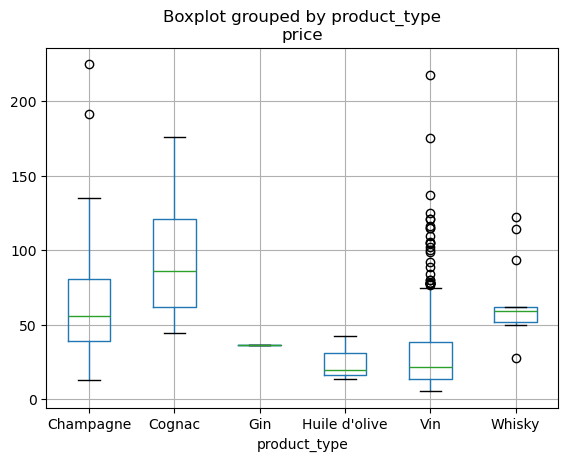

In [66]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt

df_final.boxplot(column="price",by="product_type")
plt.show()

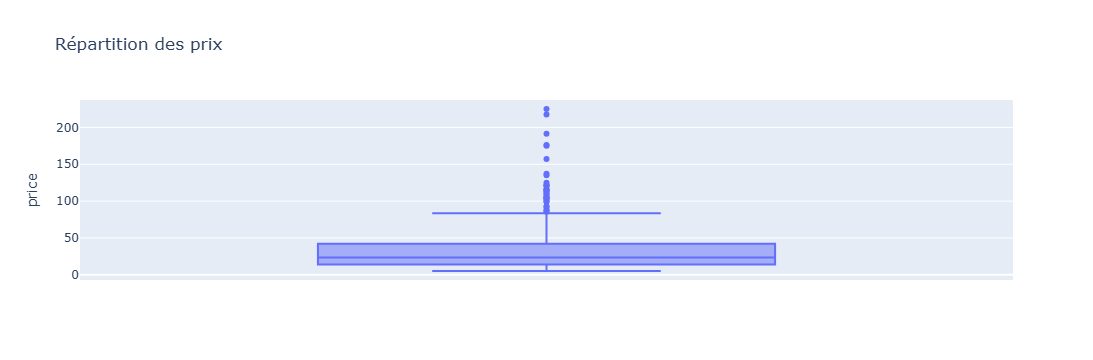

In [67]:
#Autre méthode avec plotly express
import plotly.express as px

fig = px.box(df_final, y="price", title="Répartition des prix")
fig.show()

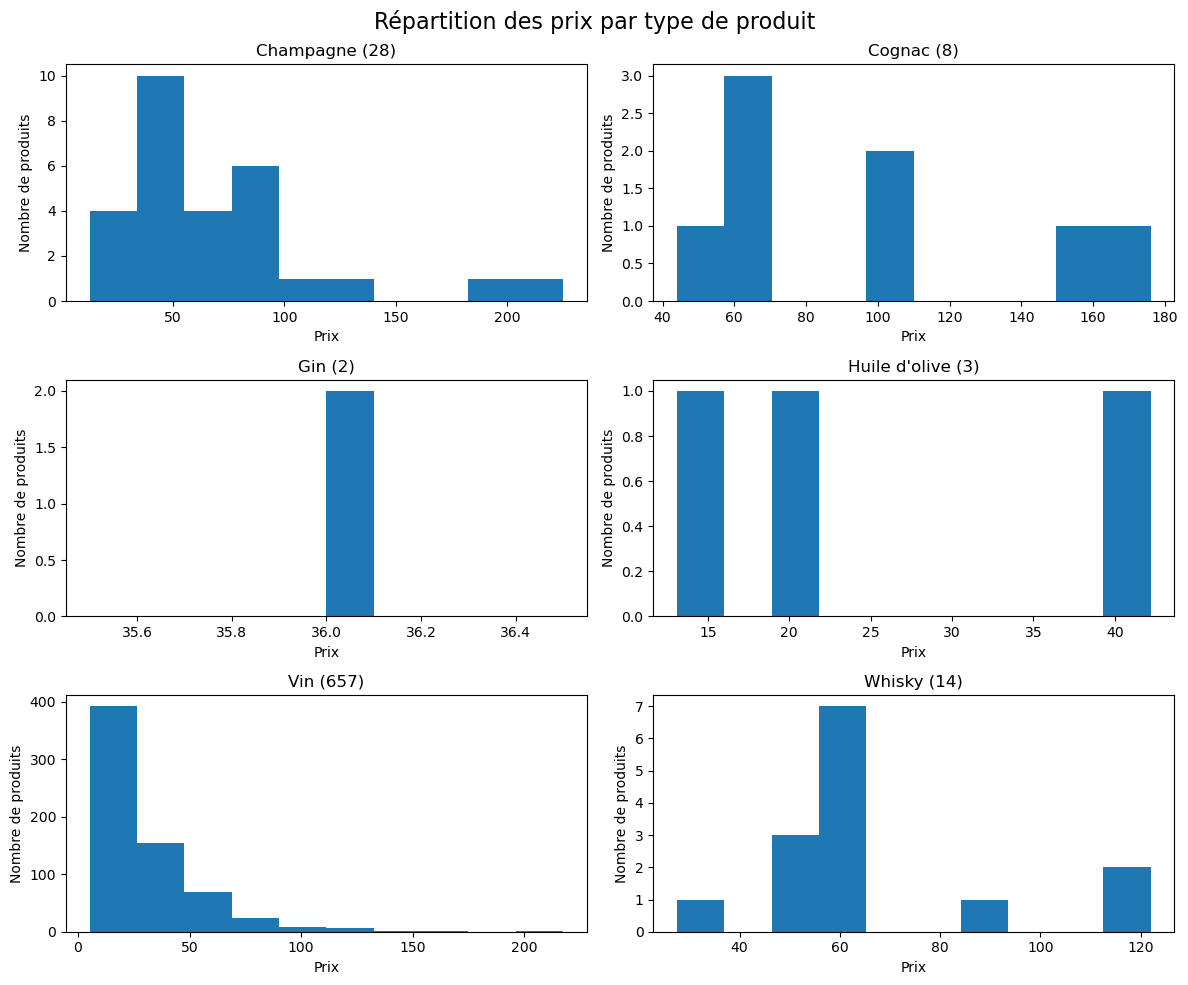

In [68]:
import matplotlib.pyplot as plt

types_produits = [
    "Champagne",
    "Cognac",
    "Gin",
    "Huile d'olive",
    "Vin",
    "Whisky"
]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for ax, type_produit in zip(axes.flatten(), types_produits):

    donnees = df_final[
        df_final["product_type"] == type_produit
    ]["price"].dropna()

    ax.hist(donnees, bins=10)

    ax.set_title(f"{type_produit} ({len(donnees)})")
    ax.set_xlabel("Prix")
    ax.set_ylabel("Nombre de produits")

plt.suptitle("Répartition des prix par type de produit", fontsize=16)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [69]:
#Calculer la moyenne du prix
moyenne = df_final["price"].mean()
print("Moyenne :", moyenne)
#Calculer l'écart-type du prix
ecart_type = df_final["price"].std()
print("Écart-type :", ecart_type)
#Calculer le Z-score
df_final["z_score"] = (df_final["price"] - moyenne) / ecart_type
df_final[["price", "z_score"]].head()

Moyenne : 32.31661991584853
Écart-type : 27.611935508393074


,price,z_score
0,8.6,-0.858926
1,41.0,0.314479
2,39.0,0.242047
3,59.9,0.998966
4,22.5,-0.355521


In [70]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
df_final.loc[df_final['z_score']>=3,'price'].min()

116.4

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [71]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_final.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,virtual,downloadable,rating_count,average_rating,total_sales,post_author,post_date,post_date_gmt,post_modified,post_modified_gmt,post_parent,menu_order,comment_count,z_score
count,713.000000,713.000000,713.000000,713.000000,713.000000,713.0,713.0,713.0,713.0,713.000000,713.000000,713,713,713,713,713.0,713.0,713.0,7.130000e+02
mean,5031.621318,0.998597,32.316620,23.478261,16.896438,0.0,0.0,0.0,0.0,8.054698,1.998597,2018-08-21 22:30:01.656381440,2018-08-21 21:01:14.868162560,2020-06-20 23:47:31.953716992,2020-06-20 21:54:00.733520384,0.0,0.0,0.0,3.986215e-17
min,3847.000000,0.000000,5.200000,0.000000,2.740000,0.0,0.0,0.0,0.0,0.000000,1.000000,2018-02-08 12:58:52,2018-02-08 11:58:52,2018-02-20 15:19:23,2018-02-20 14:19:23,0.0,0.0,0.0,-9.820615e-01
25%,4280.000000,1.000000,14.050000,9.000000,7.240000,0.0,0.0,0.0,0.0,5.000000,2.000000,2018-02-27 14:18:27,2018-02-27 13:18:27,2020-06-19 17:55:02,2020-06-19 15:55:02,0.0,0.0,0.0,-6.615480e-01
50%,4795.000000,1.000000,23.400000,20.000000,12.280000,0.0,0.0,0.0,0.0,8.000000,2.000000,2018-04-19 14:48:15,2018-04-19 12:48:15,2020-08-04 09:30:07,2020-08-04 07:30:07,0.0,0.0,0.0,-3.229263e-01
75%,5711.000000,1.000000,42.000000,30.000000,22.030000,0.0,0.0,0.0,0.0,11.000000,2.000000,2019-01-31 14:39:08,2019-01-31 13:39:08,2020-08-25 10:35:02,2020-08-25 08:35:02,0.0,0.0,0.0,3.506954e-01
max,7338.000000,1.000000,225.000000,145.000000,137.810000,0.0,0.0,0.0,0.0,36.000000,2.000000,2020-07-20 11:00:00,2020-07-20 09:00:00,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,0.0,0.0,6.978264e+00
std,790.669701,0.037450,27.611936,22.217449,14.836412,0.0,0.0,0.0,0.0,4.164265,0.037450,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.000000e+00


In [72]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_final["price"].quantile(0.25)
Q3 = df_final["price"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print("Borne inférieure :", borne_inf)
print("Borne supérieure :", borne_sup)

outliers = df_final[(df_final["price"] < borne_inf) | (df_final["price"] > borne_sup)]
outliers

Borne inférieure : -27.874999999999996
Borne supérieure : 83.925


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,z_score
22,4404.0,1.0,108.5,17.0,instock,52.22,3507,3507,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2018-03-22 11:32:55,2018-03-22 10:32:55,Cognac,Cognac Frapin Château de Fontpinot XO,"Exclusivement vendangé, distillé, vieilli et m...",publish,closed,closed,cognac-frapin-fontpinot-xo,2020-08-12 09:30:16,2020-08-12 07:30:16,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.759074
23,4407.0,1.0,104.0,14.0,instock,46.71,3509,3509,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2018-03-22 11:49:53,2018-03-22 10:49:53,Cognac,Cognac Frapin Cigar Blend,Ce cognac bénéficie d'un vieillissement plus l...,publish,closed,closed,cognac-frapin-cigar-blend,2020-07-04 09:45:03,2020-07-04 07:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.596101
24,4402.0,1.0,176.0,11.0,instock,78.25,3510,3510,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-03-22 11:21:05,2018-03-22 10:21:05,Cognac,Cognac Frapin VIP XO,La cuvée VIP XO à été enrichie d’eaux-de-vie t...,publish,closed,closed,cognac-frapin-vip-xo,2020-08-22 11:35:03,2020-08-22 09:35:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,5.203669
33,4406.0,1.0,157.0,12.0,instock,69.08,7819,7819,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2018-03-22 11:42:48,2018-03-22 10:42:48,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Eau-de-Vie distillée à partir de raisins de Gr...,publish,closed,closed,cognac-frapin-chateau-de-fontpinot-1989-20-ans,2020-03-14 16:05:04,2020-03-14 15:05:04,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,4.515561
53,6214.0,1.0,99.0,9.0,instock,49.62,11601,11601,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2019-07-25 09:15:41,2019-07-25 07:15:41,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,La couleur rouge intense annonce un belle conc...,publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-champa...,2020-07-04 11:35:02,2020-07-04 09:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.415020
54,5008.0,1.0,105.0,12.0,instock,56.42,11602,11602,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2018-07-17 10:52:41,2018-07-17 08:52:41,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-23 15:35:02,2020-06-23 13:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.632317
56,4132.0,1.0,88.4,7.0,instock,44.30,11668,11668,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2018-02-13 11:43:55,2018-02-13 10:43:55,Vin,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,Le nez dévoile déjà une belle intensité de fru...,publish,closed,closed,zind-humbrecht-pinot-gris-grand-cru-rangen-de-...,2020-02-20 09:55:02,2020-02-20 08:55:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.031128
87,6215.0,1.0,115.0,14.0,instock,56.45,12790,12790,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2019-07-25 09:30:16,2019-07-25 07:30:16,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,La couleur rouge intense annonce un belle conc...,publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-champa...,2019-11-04 09:30:25,2019-11-04 08:30:25,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.994480
88,5007.0,1.0,105.0,15.0,instock,55.88,12791,12791,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-07-17 10:36:03,2018-07-17 08:36:03,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-07-02 09:30:03,2020-07-02 07:30:03,0.0,https://www.bottle-neck.fr/?post_

In [73]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
nb_outliers = len(outliers)

proportion = nb_outliers / len(df_final) * 100

print("Nombre d'outliers :", nb_outliers)
print("Proportion :", round(proportion, 2), "%")

Nombre d'outliers : 31
Proportion : 4.35 %


In [74]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
# Les outliers correspondent à des bouteilles dont le prix est
# significativement plus élevé que le reste du catalogue.
# Ils peuvent être justifiés s'il s'agit de grands crus ou de vins rares.
# Pour le vérifier, il faut consulter les informations des produits concernés.

# agrégation des prix des outliers par type de produit
display(outliers.groupby('product_type').agg({'price': 'mean','product_id':'count'}))


df_final[df_final["price"] > borne_sup][
    ["product_id", "post_title", "price", "purchase_price"]
]



,price,product_id
product_type,,
Champagne,139.283333,6
Cognac,136.375000,4
Vin,119.422222,18
Whisky,109.666667,3


,product_id,post_title,price,purchase_price
22,4404.0,Cognac Frapin Château de Fontpinot XO,108.5,52.22
23,4407.0,Cognac Frapin Cigar Blend,104.0,46.71
24,4402.0,Cognac Frapin VIP XO,176.0,78.25
33,4406.0,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,69.08
53,6214.0,Domaine des Comtes Lafon Volnay 1er Cru Champa...,99.0,49.62
54,5008.0,Domaine des Comtes Lafon Volnay 1er Cru Santen...,105.0,56.42
56,4132.0,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,88.4,44.30
87,6215.0,Domaine des Comtes Lafon Volnay 1er Cru Champa...,115.0,56.45
88,5007.0,Domaine des Comtes Lafon Volnay 1er Cru Santen...,105.0,55.88
89,4582.0,Château de Meursault Puligny-Montrachet 1er Cr...,109.6,53.80


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [75]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article

df_final["ca_par_article"] = df_final["price"] * df_final["total_sales"]

#Calculer la somme de la colonne "ca_par_article"
df_final.sort_values("ca_par_article", ascending=False)[
    ["product_id", "ca_par_article"]
].head(10)

#Ce résultat correspond au chiffre d'affaire du site web
ca_total = df_final["ca_par_article"].sum()
print("Le chiffre d'affaires du site web est de :", ca_total, "€")

Le chiffre d'affaires du site web est de : 143324.1 €


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,z_score,ca_par_article
0,4352.0,1.0,225.0,0.0,outofstock,137.81,15940,15940,0.0,0.0,0.0,0.0,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,6.978264,2475.0
1,5892.0,1.0,191.3,98.0,instock,116.06,14983,14983,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,5.757777,1147.8
2,4353.0,1.0,79.5,127.0,instock,45.91,12587,12587,0.0,0.0,0.0,0.0,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1.708804,1113.0
3,5826.0,1.0,41.2,34.0,instock,21.71,15325,15325,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,0.321722,824.0
4,6212.0,1.0,115.0,16.0,instock,59.42,13996,13996,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.994480,805.0
5,5026.0,1.0,86.8,101.0,instock,50.13,13913,13913,0.0,0.0,0.0,0.0,9.0,taxable,2.0,2018-07-18 10:46:30,2018-07-18 08:46:30,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,"Légèrement praliné au nez, nerveux, frais, inc...",publish,closed,closed,champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 14:35:02,2020-05-11 12:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1.973182,781.2
6,5008.0,1.0,105.0,12.0,instock,56.42,11602,11602,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2018-07-17 10:52:41,2018-07-17 08:52:41,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-23 15:35:02,2020-06-23 13:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,2.632317,735.0
7,5767.0,1.0,175.0,12.0,instock,90.42,15185,15185,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2019-03-13 14:43:22,2019-03-13 13:43:22,Vin,Camille Giroud Clos de Vougeot 2016,<div>Ce vin provient de vignes âgées de 50 ans...,publish,closed,closed,camille-giroud-clos-de-vougeot-2016,2020-06-11 15:25:04,2020-06-11 13:25:04,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,5.167453,700.0
8,6126.0,1.0,135.0,138.0,instock,80.33,14923,14923,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2019-06-28 17:22:27,2019-06-28 15:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,Une robe somptueuse a la teinte jaune pâle eti...,publ

C:\Users\imanb\AppData\Local\Temp\ipykernel_19464\363773407.py:18: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['4352.0' '5892.0' '4353.0' '5826.0' '6212.0' '5026.0' '5008.0' '5767.0'
 '6126.0' '5025.0' '6201.0' '4406.0' '4647.0' '4358.0' '4359.0' '6214.0'
 '6202.0' '4350.0' '4573.0' '4402.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



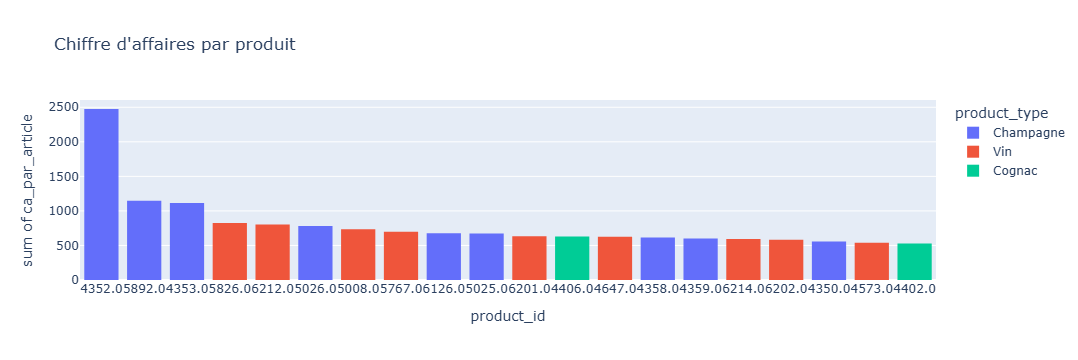

In [76]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_final
df_final = df_final.sort_values("ca_par_article", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_final = df_final.reset_index(drop=True)

#Afficher les 20 premiers articles en CA

display(df_final.iloc[:20, :])


# Création d'une copie afin de pouvoir modifier le format des donnnées de product_id
data_ca = df_final.iloc[:20,:].copy()  
data_ca.loc[:,'product_id'] = data_ca['product_id'].astype(str)
# fixer l'ordre des product_id
ordre_ca = list(data_ca['product_id'].astype(str))
# création du graphique
fig3 = px.histogram(data_ca, x='product_id', y='ca_par_article', color='product_type', title="Chiffre d'affaires par produit", category_orders={"product_id": ordre_ca})
fig3.show()




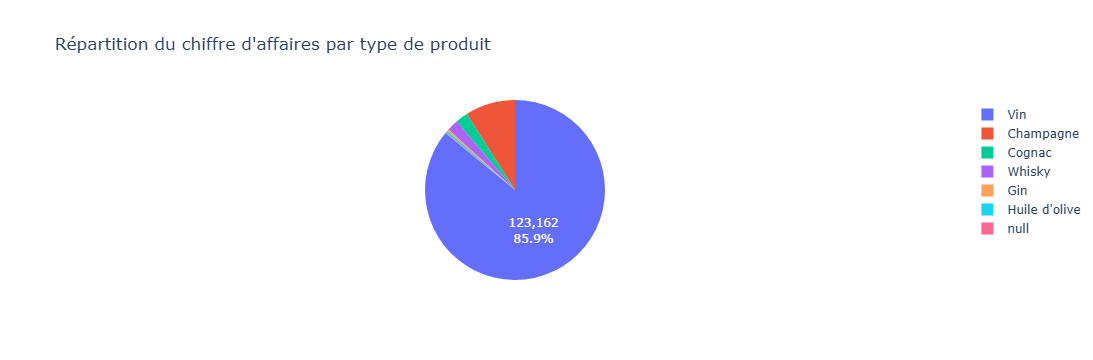

In [77]:
# Répartition du chiffre d'affaires par type de produit

fig8 = px.pie(df_final, values='ca_par_article', names='product_type', title="Répartition du chiffre d'affaires par type de produit")
fig8.update_traces(textposition='inside',textinfo='percent+value')
fig8.update_layout(uniformtext_minsize=10, uniformtext_mode='hide')
fig8.show()

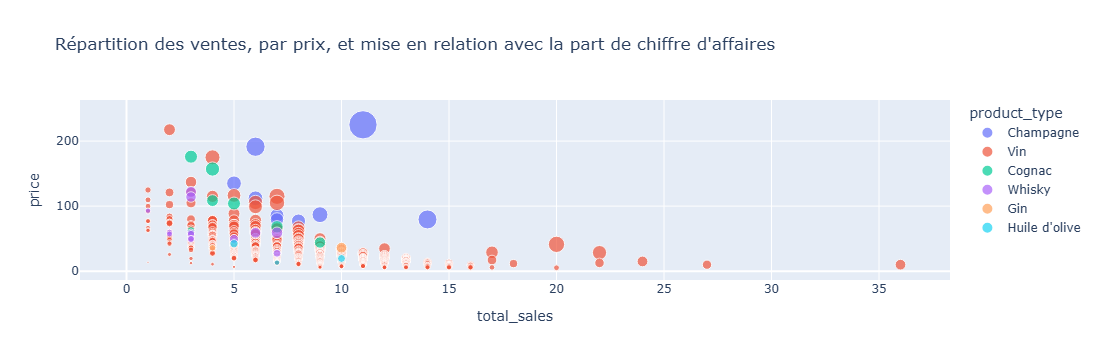

In [78]:
# Nuage de point de mise en relation entre le volume vendu, le prix et la part de chiffre d'affaires

fig10 = px.scatter(df_final, x="total_sales", y="price", color="product_type",size='ca_par_article', title="Répartition des ventes, par prix, et mise en relation avec la part de chiffre d'affaires")
fig10.show()

In [79]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_final["part_ca"] = df_final["ca_par_article"] / df_final["ca_par_article"].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final["part_ca_cumulee"] = df_final["part_ca"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
articles_80 = df_final[df_final["part_ca_cumulee"] <= 0.8]
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion = len(articles_80) / len(df_final) * 100
# Nombre de produits
print("Nombre de produits :", len(articles_80))

proportion = len(articles_80) / len(df_final) * 100
print("Proportion :", round(proportion, 2), "%")


Nombre de produits : 433
Proportion : 60.73 %


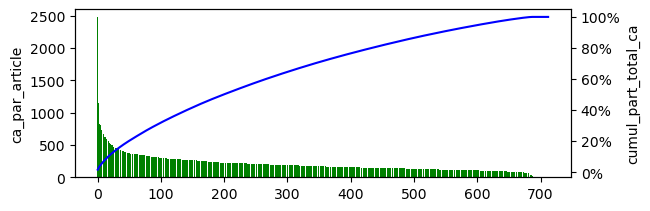

In [80]:
# COURBE PARETO 

# liste des données utilisées
ordre = df_final.index
ca = df_final['ca_par_article']
percent_ca = df_final["part_ca_cumulee"]

# création du graphique CA
plt.subplot(2, 1, 1)
ca_id = plt.bar(ordre, ca, color='green')  
plt.ylabel('ca_par_article')

# création du graphique cumul pourcentage CA
plt.twinx()
cumul_ca = plt.plot(ordre, percent_ca, color='blue')
plt.ylabel('cumul_part_total_ca')
ax2 = plt.gca()
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,z_score,ca_par_article,part_ca,part_ca_cumulee
0,4867.0,1.0,9.9,121.0,instock,4.86,16148,16148,0.0,0.0,0.0,0.0,36.0,taxable,2.0,2018-05-03 13:20:05,2018-05-03 11:20:05,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,"<div>\n\nUn rosé minéral, fruité et d’une gran...",publish,closed,closed,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.811845,356.4,0.002487,0.228560
1,4203.0,1.0,9.9,74.0,instock,5.01,15415,15415,0.0,0.0,0.0,0.0,27.0,taxable,2.0,2018-02-15 14:33:42,2018-02-15 13:33:42,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin de gourmandise à boire sur la fraîcheur po...,publish,closed,closed,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 16:45:03,2020-07-11 14:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.811845,267.3,0.001865,0.400906
2,4275.0,1.0,14.9,62.0,instock,7.78,14864,14864,0.0,0.0,0.0,0.0,24.0,taxable,2.0,2018-02-27 13:33:54,2018-02-27 12:33:54,Vin,I Fabbri Chianti Classico Lamole 2017,Un nez typique de petits fruits rouges. Une bo...,publish,closed,closed,i-fabbri-chianti-classico-lamole-2017,2020-08-22 14:35:02,2020-08-22 12:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.630764,357.6,0.002495,0.216111
3,4647.0,1.0,28.5,45.0,instock,14.14,16525,16525,0.0,0.0,0.0,0.0,22.0,taxable,2.0,2018-04-17 09:28:58,2018-04-17 07:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"Sur ce sol très calcaire, la Croix Boissée dél...",publish,closed,closed,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.138224,627.0,0.004375,0.082447
4,4726.0,1.0,12.7,0.0,outofstock,6.82,14950,14950,0.0,0.0,0.0,0.0,22.0,taxable,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,Vin,François Baur Pinot Noir Schlittweg 2017,"Un éclat de fruits, de la souplesse, de la ron...",publish,closed,closed,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.710440,279.4,0.001949,0.366504
5,6129.0,1.0,5.2,68.0,instock,2.74,14570,14570,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-06-28 18:01:06,2019-06-28 16:01:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Nez Séduisant et puissant. Bouquet de fleurs j...,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,2020-08-26 15:55:02,2020-08-26 13:55:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.982062,104.0,0.000726,0.952581
6,5826.0,1.0,41.2,34.0,instock,21.71,15325,15325,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,0.321722,824.0,0.005749,0.038792
7,4220.0,1.0,11.6,48.0,instock,5.75,15758,15758,0.0,0.0,0.0,0.0,18.0,taxable,2.0,2018-02-16 10:54:27,2018-02-16 09:54:27,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,"Un Touraine Amboise fin et élégant, un joli ch...",publish,closed,closed,frissant-chenin-pierres-2018,2020-08-27 11:45:02,2020-08-27 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.750278,208.8,0.001457,0.577962
8,5778.0,1.0,5.8,44.0,instock,3.09,15561,15561,0.0,0.0,0.0,0.0,17.0,taxable,2.0,2019-03-15 10:20:59,2019-03-15

C:\Users\imanb\AppData\Local\Temp\ipykernel_19464\1250568916.py:21: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['4867.0' '4203.0' '4275.0' '4647.0' '4726.0' '6129.0' '5826.0' '4220.0'
 '5778.0' '5803.0' '6569.0' '4188.0' '5777.0' '4870.0' '4105.0' '5695.0'
 '4059.0' '4863.0' '4261.0' '4204.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



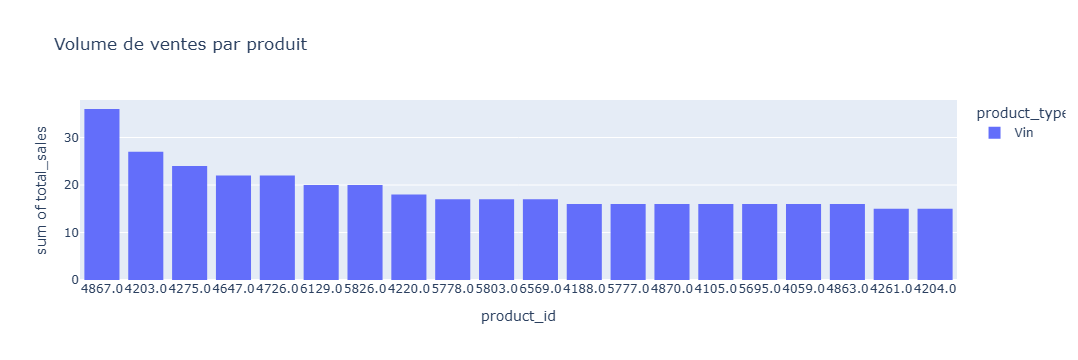

np.float64(5743.0)

In [81]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_final = df_final.sort_values('total_sales', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_final = df_final.sort_values(
    by='total_sales',
    ascending=False
).reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
display(df_final.iloc[:20, :])

#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px

# création d'une copie du dataframe pour changer le format du product_id
data_vol = df_final.iloc[:20,:].copy()  
data_vol.loc[:,'product_id'] = data_vol['product_id'].astype(str)  
# fixer l'ordre des product_id
ordre_qte = list(data_vol['product_id'].astype(str))
# création du graphique
fig4 = px.histogram(data_vol, x='product_id', y='total_sales', title='Volume de ventes par produit', color='product_type', category_orders={"product_id": ordre_qte})
fig4.show()

# Quantités vendues au total
df_final['total_sales'].sum()


In [82]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_final["part_qte"] = df_final["total_sales"] / df_final["total_sales"].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final["part_qte_cumulee"] = df_final["part_qte"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
articles_80_qte = df_final[df_final["part_qte_cumulee"] <= 0.8]
len(articles_80_qte)

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_qte = len(articles_80_qte) / len(df_final) * 100

print("Proportion :", round(proportion_qte, 2), "%")

Proportion : 60.59 %


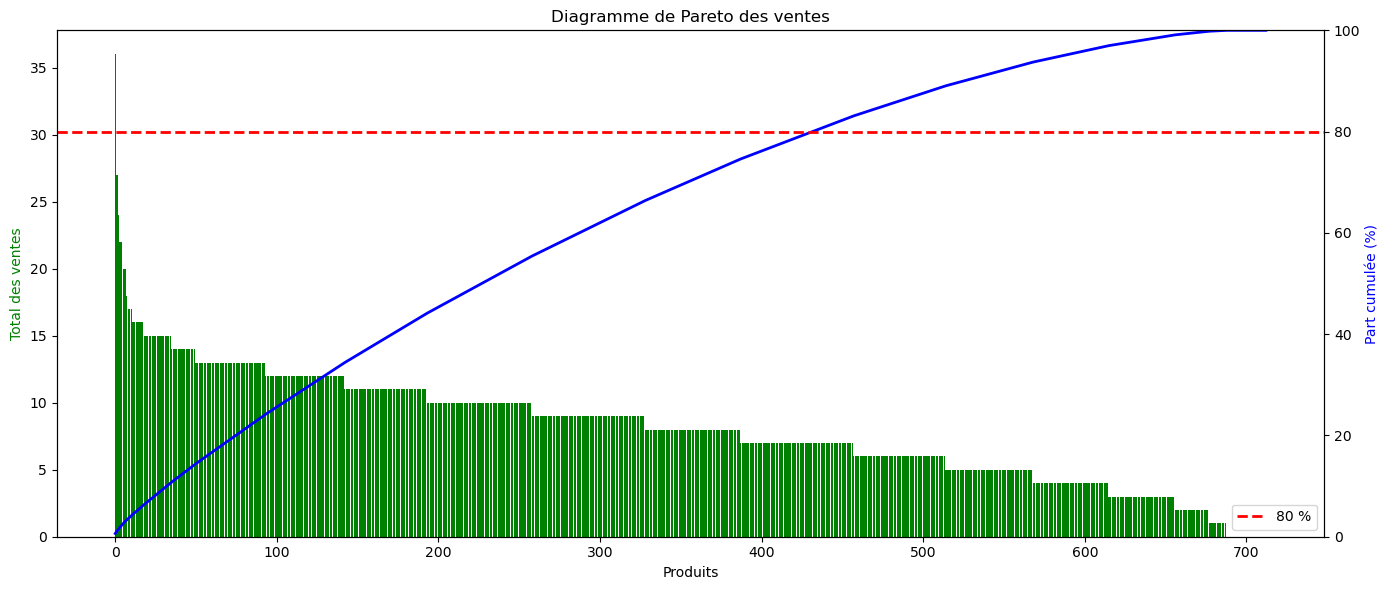

In [83]:
# COURBE PARETO


# liste des données utilisées
ordre = df_final.index
ca = df_final['total_sales']
percent_ca = df_final['part_qte_cumulee']

# création du graphique CA
import matplotlib.pyplot as plt

# 1. Trier les données par total_sales (du plus grand au plus petit)
df_pareto = df_final.sort_values(
    by="total_sales",
    ascending=False
).reset_index(drop=True)

# 2. Recalculer la part et le cumul
df_pareto["part_qte"] = (
    df_pareto["total_sales"] / df_pareto["total_sales"].sum()
)

df_pareto["part_qte_cumulee"] = df_pareto["part_qte"].cumsum()

# 3. Création du graphique
fig, ax1 = plt.subplots(figsize=(14, 6))

# Histogramme
ax1.bar(
    df_pareto.index,
    df_pareto["total_sales"],
    color="green"
)
ax1.set_xlabel("Produits")
ax1.set_ylabel("Total des ventes", color="green")

# Courbe cumulée
ax2 = ax1.twinx()
ax2.plot(
    df_pareto.index,
    df_pareto["part_qte_cumulee"] * 100,
    color="blue",
    linewidth=2
)

ax2.set_ylabel("Part cumulée (%)", color="blue")
ax2.set_ylim(0, 100)

# Ligne des 80 %
ax2.axhline(
    y=80,
    color="red",
    linestyle="--",
    linewidth=2,
    label="80 %"
)

ax2.legend(loc="lower right")

plt.title("Diagramme de Pareto des ventes")
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,z_score,ca_par_article,part_ca,part_ca_cumulee,part_qte,part_qte_cumulee,rotation_de_stock,nombre_mois_stockage
0,6129.0,1.0,5.2,68.0,instock,2.74,14570,14570,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-06-28 18:01:06,2019-06-28 16:01:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Nez Séduisant et puissant. Bouquet de fleurs j...,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,2020-08-26 15:55:02,2020-08-26 13:55:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.982062,104.0,0.000726,0.952581,0.003483,0.026293,446.715328,14.890511
1,5779.0,1.0,5.8,30.0,instock,2.88,16213,16213,0.0,0.0,0.0,0.0,9.0,taxable,2.0,2019-03-15 10:24:21,2019-03-15 09:24:21,Vin,Maurel Pays d'Oc Syrah 2019,<div>Une Syrah fraîche et gouleyante. Une très...,publish,closed,closed,maurel-pays-d-oc-syrah-2019,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.960332,52.2,0.000364,0.998764,0.001567,0.629636,416.666667,13.888889
2,4174.0,1.0,5.7,43.0,instock,2.92,16209,16209,0.0,0.0,0.0,0.0,13.0,taxable,2.0,2018-02-14 17:15:31,2018-02-14 16:15:31,Vin,Maurel Cabardès Tradition 2017,"Un joli nez aux arômes de fruits rouges, de ca...",publish,closed,closed,maurel-cabardes-tradition-2017,2020-08-05 18:05:03,2020-08-05 16:05:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.963953,74.1,0.000517,0.995258,0.002264,0.171687,407.797682,13.593256
3,4173.0,1.0,5.7,49.0,instock,2.97,16211,16211,0.0,0.0,0.0,0.0,15.0,taxable,2.0,2018-02-14 17:10:39,2018-02-14 16:10:39,Vin,Maurel Pays d'Oc Chenin-Colombard 2019,Ce vin d'une grande fraîcheur est élaboré à pa...,publish,closed,closed,maurel-pays-doc-chenin-colombard-2019,2020-08-07 17:35:03,2020-08-07 15:35:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.963953,85.5,0.000597,0.985318,0.002612,0.103082,395.959596,13.198653
4,4148.0,1.0,37.5,71.0,instock,21.88,1364,1364,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-02-13 13:36:44,2018-02-13 12:36:44,Champagne,Champagne Mailly Grand Cru Brut Rosé,Une somptueuse robe rose lumineuse habille cet...,publish,closed,closed,champagne-mailly-grand-cru-brut-rose,2020-08-08 10:45:03,2020-08-08 08:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,0.187722,112.5,0.000785,0.925398,0.000522,0.989727,389.396709,12.979890


C:\Users\imanb\AppData\Local\Temp\ipykernel_19464\1057889113.py:27: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['6129.0' '5779.0' '4174.0' '4173.0' '4148.0' '5777.0' '5761.0' '4357.0'
 '4776.0' '4142.0' '4208.0' '4963.0' '4927.0' '4739.0' '4680.0' '4172.0'
 '4356.0' '4755.0' '5778.0' '4863.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



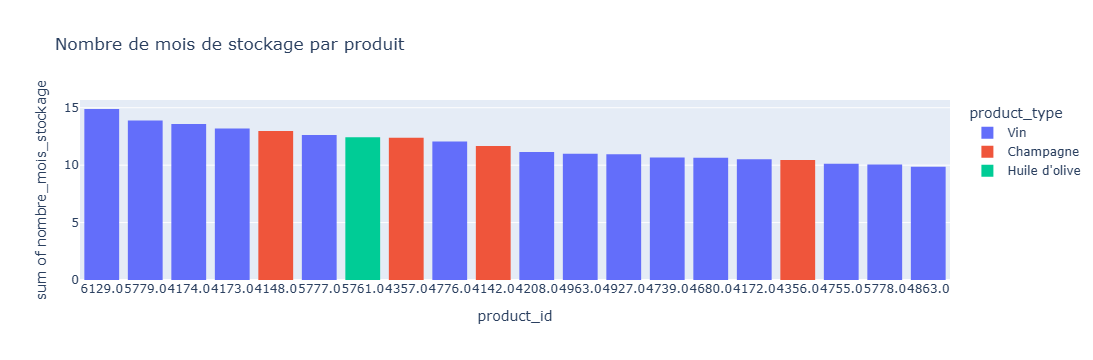

In [84]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np
#Création de la colonne Rotation de stock
#  Rotation des stocks = Stocks de marchandises / Coût d'achat des marchandises vendues (HT) x 360
cout_achat_produits_vendus = df_final['total_sales']*df_final['purchase_price']
df_final['rotation_de_stock'] = (df_final['stock_quantity']/cout_achat_produits_vendus)*360

#Remplacement des "inf" par 0
df_final.loc[np.isinf(df_final['rotation_de_stock'])==True,'rotation_de_stock']=0


#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
# durée moyenne de stockage = octobre : 1 mois / rotation des stocks
df_final['nombre_mois_stockage'] = df_final['rotation_de_stock']/30
df_final.loc[np.isinf(df_final['nombre_mois_stockage'])==True,'nombre_mois_stockage']=0
df_final = df_final.sort_values('nombre_mois_stockage', ascending=False)
df_final = df_final.reset_index(drop=True)
display(df_final.head())

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
# copie du dataframe pour changer le format du product_id
data_stock = df_final.iloc[:20,:].copy()  
data_stock.loc[:,'product_id'] = data_stock['product_id'].astype(str)  
# fixation de l'ordre des product_id
ordre_stock = list(df_final['product_id'].astype(str))
fig5 = px.histogram(data_stock, x='product_id', y='nombre_mois_stockage', color='product_type', title='Nombre de mois de stockage par produit', category_orders={"product_id": ordre_stock})
fig5.show()

In [85]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_final['valorisation_stocks_euros'] = df_final['stock_quantity']*df_final['purchase_price']
#Calculer la somme de la colonne "Valorisation_stock_euros"

total_valorisation = round(df_final['valorisation_stocks_euros'].sum(),2)
print(total_valorisation)

277328.07


In [86]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
total_stock = df_final['stock_quantity'].sum()
print(total_stock)

16740.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [87]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
df_final['prix_HT']=df_final['price']-(20/100*df_final['price'])

#Création de la colonne Taux de marge
marge_brute = df_final['prix_HT']-df_final['purchase_price']
df_final['taux_marge']=round((marge_brute/df_final['purchase_price'])*100,2)
display(df_final.head())

#Afficher le prix minimum de la colonne "taux_marge"
print(df_final['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print(df_final['taux_marge'].max())

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,z_score,ca_par_article,part_ca,part_ca_cumulee,part_qte,part_qte_cumulee,rotation_de_stock,nombre_mois_stockage,valorisation_stocks_euros,prix_HT,taux_marge
0,6129.0,1.0,5.2,68.0,instock,2.74,14570,14570,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-06-28 18:01:06,2019-06-28 16:01:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Nez Séduisant et puissant. Bouquet de fleurs j...,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,2020-08-26 15:55:02,2020-08-26 13:55:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.982062,104.0,0.000726,0.952581,0.003483,0.026293,446.715328,14.890511,186.32,4.16,51.82
1,5779.0,1.0,5.8,30.0,instock,2.88,16213,16213,0.0,0.0,0.0,0.0,9.0,taxable,2.0,2019-03-15 10:24:21,2019-03-15 09:24:21,Vin,Maurel Pays d'Oc Syrah 2019,<div>Une Syrah fraîche et gouleyante. Une très...,publish,closed,closed,maurel-pays-d-oc-syrah-2019,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.960332,52.2,0.000364,0.998764,0.001567,0.629636,416.666667,13.888889,86.40,4.64,61.11
2,4174.0,1.0,5.7,43.0,instock,2.92,16209,16209,0.0,0.0,0.0,0.0,13.0,taxable,2.0,2018-02-14 17:15:31,2018-02-14 16:15:31,Vin,Maurel Cabardès Tradition 2017,"Un joli nez aux arômes de fruits rouges, de ca...",publish,closed,closed,maurel-cabardes-tradition-2017,2020-08-05 18:05:03,2020-08-05 16:05:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.963953,74.1,0.000517,0.995258,0.002264,0.171687,407.797682,13.593256,125.56,4.56,56.16
3,4173.0,1.0,5.7,49.0,instock,2.97,16211,16211,0.0,0.0,0.0,0.0,15.0,taxable,2.0,2018-02-14 17:10:39,2018-02-14 16:10:39,Vin,Maurel Pays d'Oc Chenin-Colombard 2019,Ce vin d'une grande fraîcheur est élaboré à pa...,publish,closed,closed,maurel-pays-doc-chenin-colombard-2019,2020-08-07 17:35:03,2020-08-07 15:35:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.963953,85.5,0.000597,0.985318,0.002612,0.103082,395.959596,13.198653,145.53,4.56,53.54
4,4148.0,1.0,37.5,71.0,instock,21.88,1364,1364,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-02-13 13:36:44,2018-02-13 12:36:44,Champagne,Champagne Mailly Grand Cru Brut Rosé,Une somptueuse robe rose lumineuse habille cet...,publish,closed,closed,champagne-mailly-grand-cru-brut-rose,2020-08-08 10:45:03,2020-08-08 08:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,0.187722,112.5,0.000785,0.925398,0.000522,0.989727,389.396709,12.979890,1553.48,30.00,37.11


-86.94
83.76


In [88]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_final.loc[df_final['taux_marge']<0,:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,z_score,ca_par_article,part_ca,part_ca_cumulee,part_qte,part_qte_cumulee,rotation_de_stock,nombre_mois_stockage,valorisation_stocks_euros,prix_HT,taux_marge
690,4355.0,1.0,12.65,97.0,instock,77.48,12589,12589,0.0,0.0,0.0,0.0,0.0,taxable,2.0,2018-03-02 10:46:10,2018-03-02 09:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 10:15:02,2020-08-13 08:15:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,-0.712251,0.0,0.0,1.0,0.0,1.0,0.0,0.0,7515.56,10.12,-86.94


In [89]:
# Création d'un DataFrame avec les taux positifs
df_final_positif = df_final[df_final["taux_marge"] > 0]

# Prix minimum et maximum
print(df_final_positif["taux_marge"].min())
print(df_final_positif["taux_marge"].max())

24.32
83.76


,taux_marge
product_type,
Cognac,75.03
Whisky,74.47
Gin,67.83
Vin,55.03
Champagne,30.02
Huile d'olive,28.06


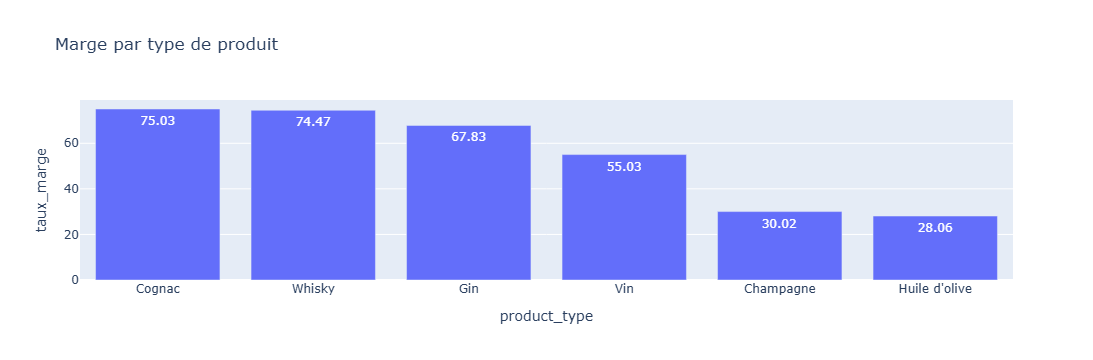

In [90]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_marge = df_final.groupby('product_type').agg({'taux_marge':'mean'}) 
df_taux_marge['taux_marge'] = df_taux_marge['taux_marge'].round(2)
df_taux_marge = df_taux_marge.sort_values(by='taux_marge', ascending=False) 
display(df_taux_marge)

#Affichage dans un graphique du taux de marge par type de produit
fig6 = px.bar(df_taux_marge, y='taux_marge', title='Marge par type de produit',text_auto=True)
fig6.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

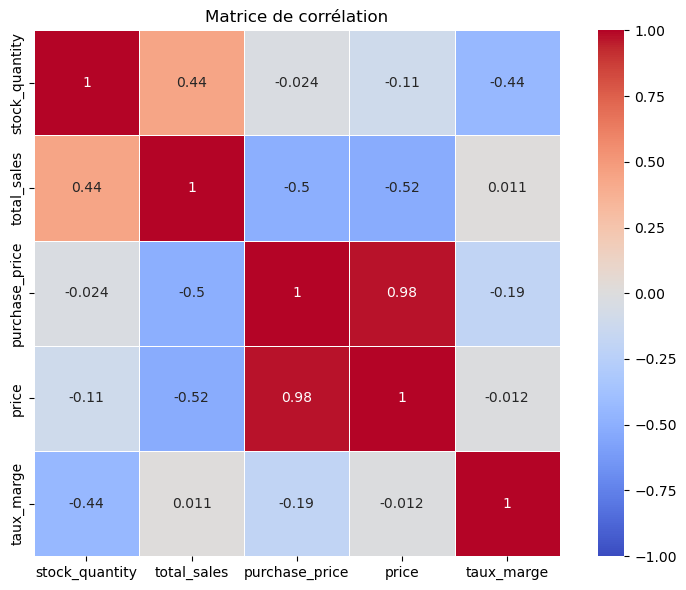

In [91]:
############################
# Analyse des corrélations #
############################

import matplotlib.pyplot as plt
import seaborn as sns

# Variables à analyser
corr_col = df_final[
    ['stock_quantity',
     'total_sales',
     'purchase_price',
     'price',
     'taux_marge']
]

# Création d'une nouvelle figure
plt.figure(figsize=(8,6))
plt.clf()

# Heatmap
sns.heatmap(
    corr_col.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=True
)

plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# Fermer la figure
plt.close()

In [92]:
#Que peut-on conclure des corrélations ?
# Aucune corrélation forte n'est observée.
# Les ventes sont faiblement corrélées au stock (0,26) et très faiblement corrélées au prix (-0,13).
# Le prix et le stock ne présentent pratiquement aucune relation (0,01).

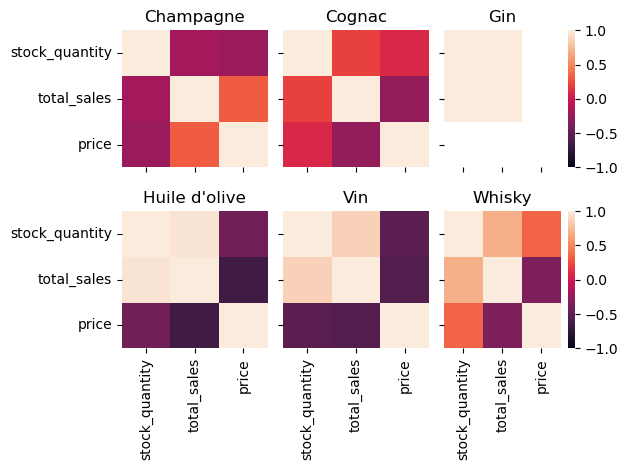

In [93]:
# création de dataframe par type de produit
corr_champagne = df_final.loc[df_final['product_type']=='Champagne',['stock_quantity','total_sales','price']]
corr_cognac = df_final.loc[df_final['product_type']=='Cognac',['stock_quantity','total_sales','price']]
corr_gin = df_final.loc[df_final['product_type']=='Gin',['stock_quantity','total_sales','price']]
corr_huile = df_final.loc[df_final['product_type']=="Huile d'olive",['stock_quantity','total_sales', 'price']]
corr_vin = df_final.loc[df_final['product_type']=='Vin',['stock_quantity','total_sales', 'price']]
corr_whisky = df_final.loc[df_final['product_type']=='Whisky',['stock_quantity','total_sales', 'price']]

# configuration de l'échelle
vmin = -1.0
vmax = 1.0

# configuration de la mise en page
fig, ((ax1, ax2, ax3),  (ax4, ax5, ax6)) = plt.subplots(2, 3, sharey=True, sharex=True)

# Création des graphiques
corr1 = sns.heatmap(corr_champagne.corr(),ax=ax1, vmin=vmin, vmax=vmax,cbar=False)
corr1.set_title("Champagne")

corr2 = sns.heatmap(corr_cognac.corr(),ax=ax2, vmin=vmin, vmax=vmax,cbar=False)
corr2.set_title("Cognac")

corr3 = sns.heatmap(corr_gin.corr(),ax=ax3, vmin=vmin, vmax=vmax)
corr3.set_title("Gin")

corr4 = sns.heatmap(corr_huile.corr(),ax=ax4, vmin=vmin, vmax=vmax,cbar=False)
corr4.set_title("Huile d'olive")

corr5 = sns.heatmap(corr_vin.corr(),ax=ax5, vmin=vmin, vmax=vmax,cbar=False)
corr5.set_title("Vin")

corr6 = sns.heatmap(corr_whisky.corr(),ax=ax6, vmin=vmin, vmax=vmax)
corr6.set_title("Whisky")

# Ajustement de la mise en page
plt.tight_layout()

# illustration
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [94]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_final.to_excel("df_final.xlsx", index=False)